# Photographing the night sky

## 0. Imports

In [1]:
import time

import astropy.units as u
import healpy as hp
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.view import (
    Camera,
    SpectralResponse,
    ToneCurve,
    add_noise,
    cie_xyz,
    render_sky,
    to_linear_srgb,
)
from nyx.emitter import Airglow, BrightStars, Moon, ZodiacalLight, gaia_star_field

plt.rcParams["figure.dpi"] = 150

## Defining scene

In [2]:
geo = Geometry(
    wvls=jnp.linspace(380, 750, 48) * u.nm,  # visible band
    nside=256,                               # ~0.46 deg map pixels
    ngrid=2,
    fov=1.0 * u.deg,                         # unused by the photograph
)

location = EarthLocation.from_geodetic(
    lon=16.50012 * u.deg, lat=-23.27232 * u.deg, height=1.835 * u.km
)
time_utc = Time("2021-06-18T21:00:00", scale="utc") + np.array([0.0]) * u.s

obs = Observation(
    location,
    time_utc,
    SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic"),  # only sets the pointing
    geo,
)

stars, starlight = gaia_star_field(geo, lim_mag=11.0)

emitters = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "starlight": starlight,
    "stars": stars,
    "bright": BrightStars.from_anderson2012(geo),
    "moon": Moon.from_jones2013(geo),
}

atmosphere = single_scattering.HGOzoneAbsorption(geo, aod_500=0.4)

E0826 13:18:20.746562 1231756 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


Determine a response field:

In [3]:
response = SpectralResponse.cie(geo.wvls)

## 2. Rendering

In [4]:
start = time.perf_counter()
sky = render_sky(obs, atmosphere, emitters, response)
print(f"rendered in {time.perf_counter() - start:.1f} s\n")
print(sky)

rendered in 23.7 s

SkyRender('sky', obs=0, nside=256, channels=3, scatter_nside=32, target_nside=32)
  hemisphere mean [tristimulus / sr]
  source           direct      indirect         total
  -----------------------------------------------------
  airglow       8.623e+10     2.423e+10     1.105e+11
  zodiacal      2.862e+10     7.336e+09     3.595e+10
  starlight     1.503e+10     3.665e+09     1.869e+10
  stars         1.446e+10     3.729e+09     1.819e+10
  bright        1.327e+09     3.275e+08     1.654e+09
  moon          2.328e+12     5.891e+11     2.917e+12
  total         2.473e+12     6.284e+11     3.102e+12


## 3. Defining a camera:


In [5]:
camera = Camera(
    az=250 * u.deg,     # looking west-southwest, towards the Moon
    alt=30 * u.deg,
    fov=90 * u.deg,
    size=(3840, 2160),
    psf=2.2,            # star image FWHM in pixels
)


def show(image, curve, title=None, ax=None, alpha=None):
    """Tone-map a linear frame and draw it."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 9 * camera.height / camera.width))
    ax.imshow(curve(image, alpha=alpha))
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10, color="0.3", loc="left")


Fitting the tone curve to the dark components:

In [6]:
dark_components = [name for name in sky.sources if name != "moon"]
dark_sky = camera.expose(sky, dark_components)
curve = ToneCurve.fit(dark_sky, level=0.16, saturation=1.35)

moon_full = camera.expose(sky)
moon_curve = ToneCurve.fit(moon_full, level=0.16, saturation=1.2)

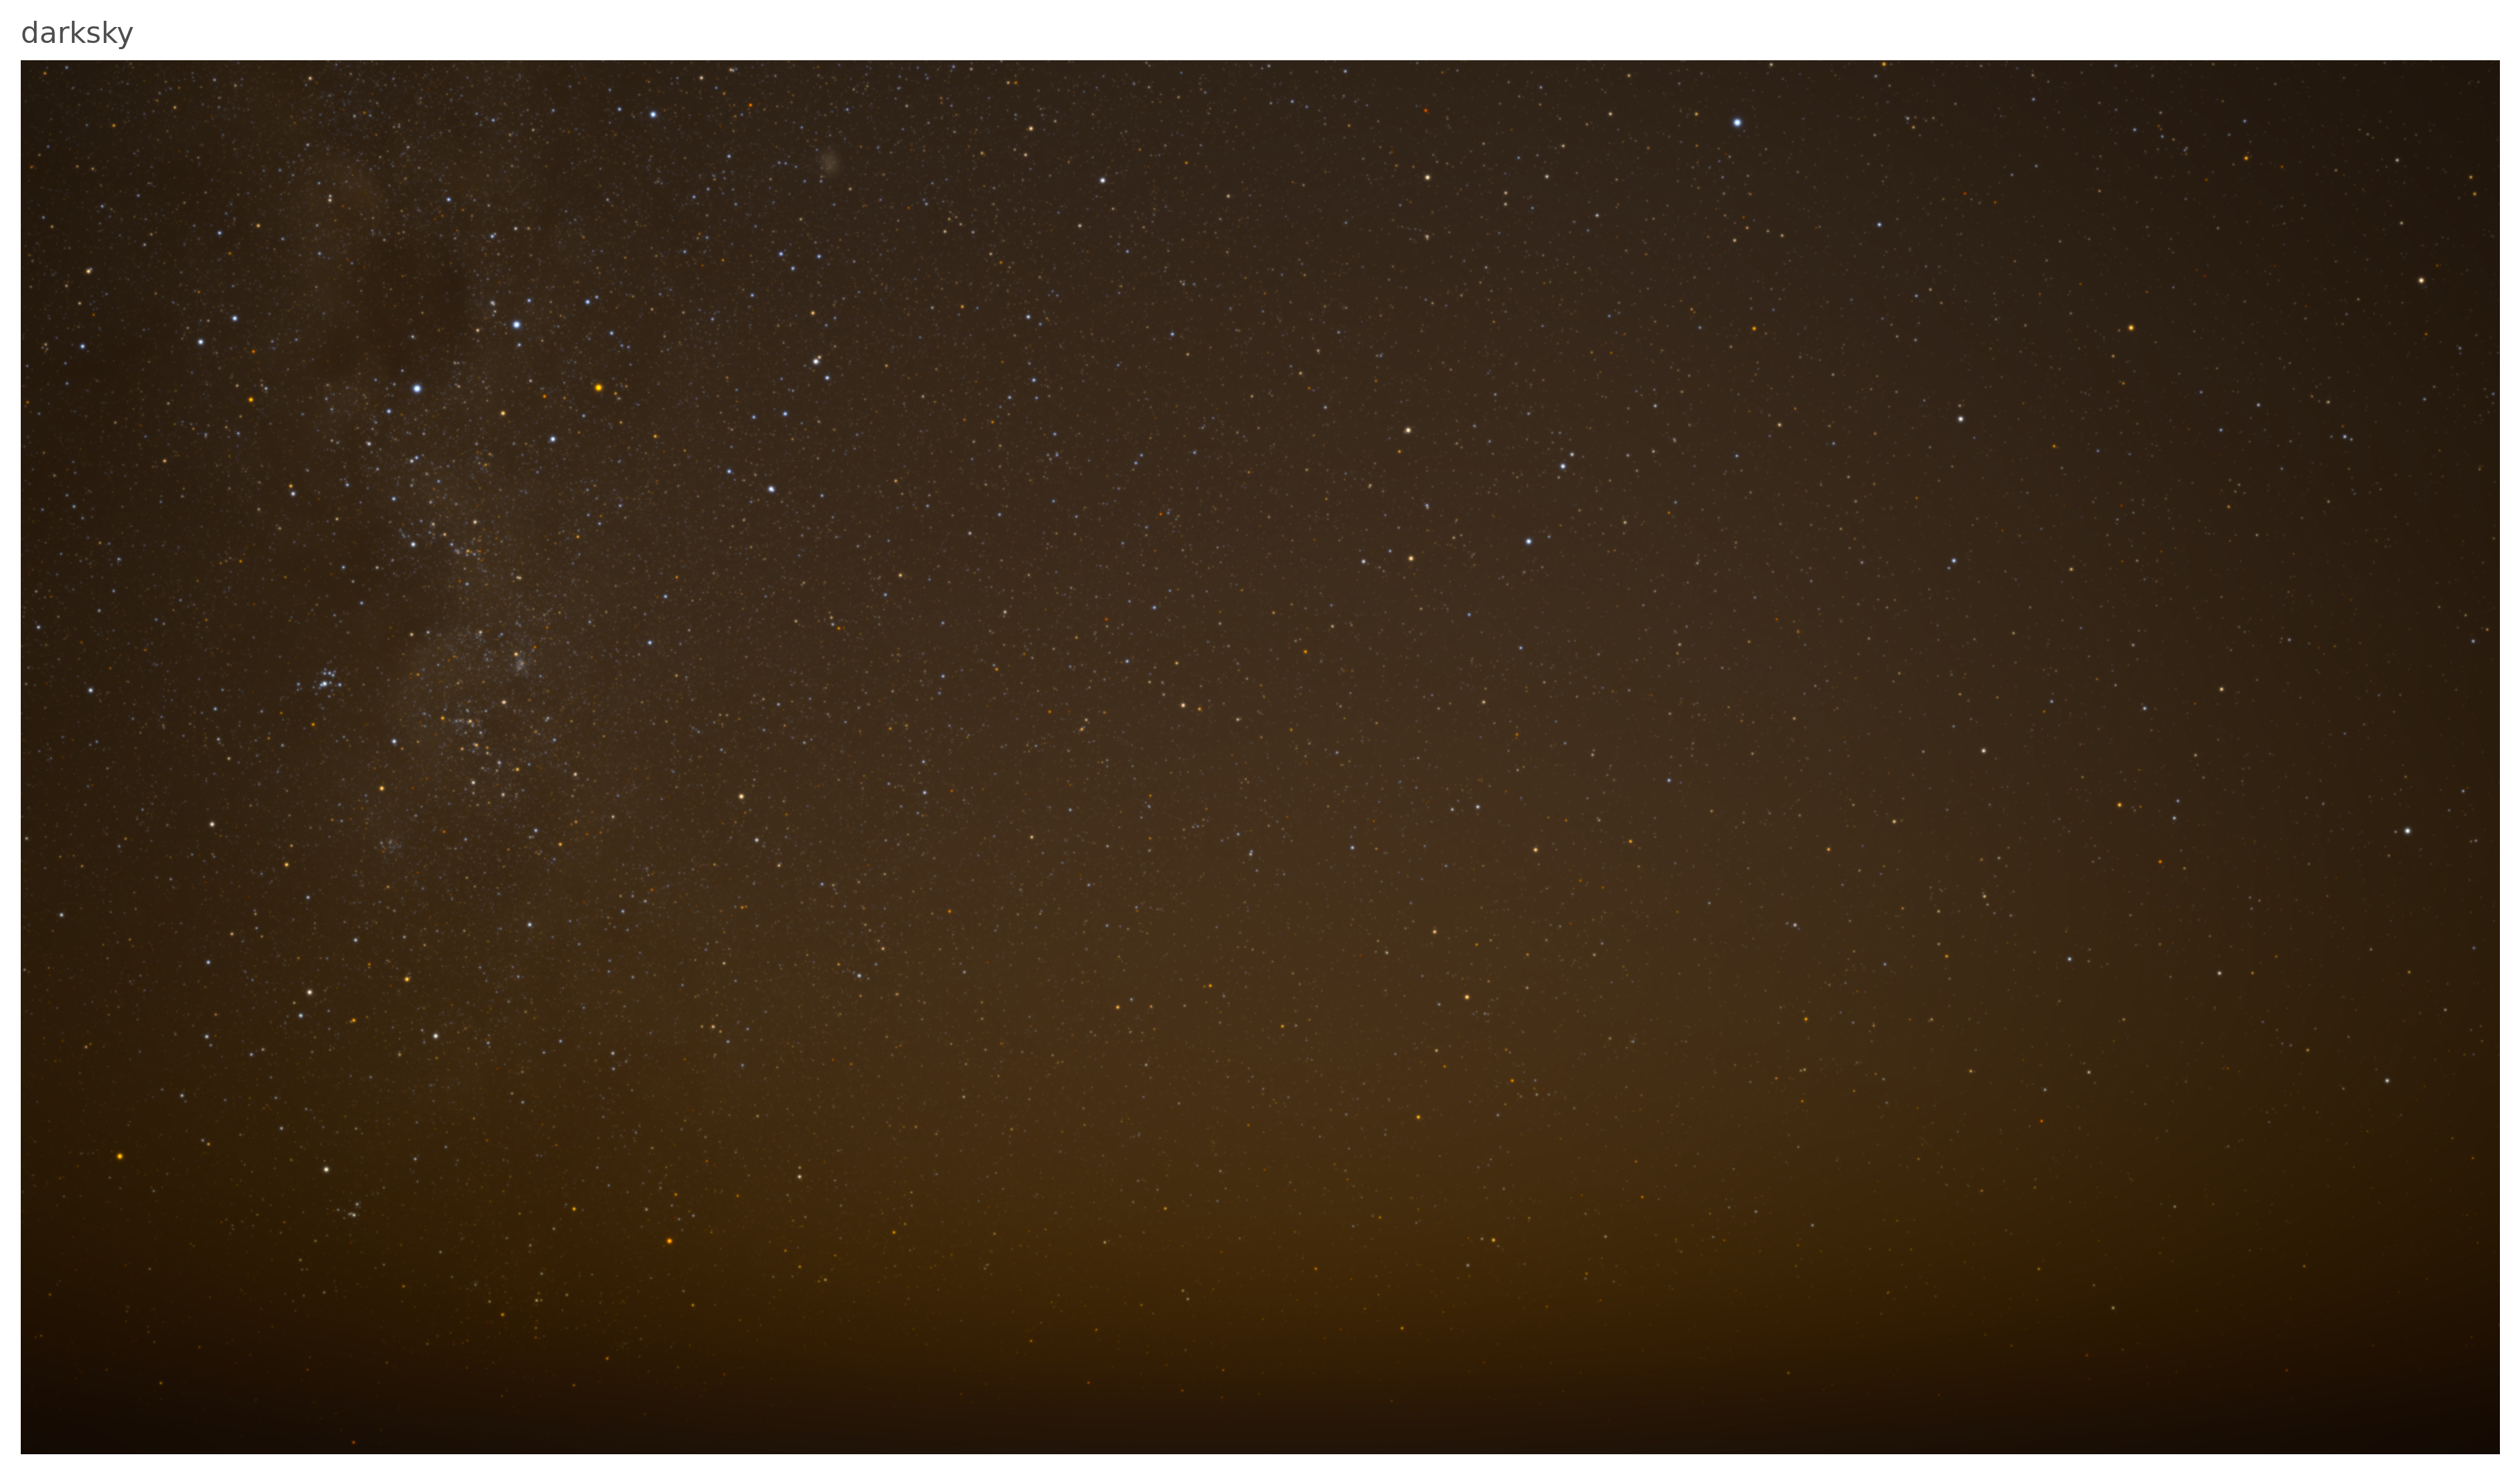

In [18]:
fig, ax = plt.subplots(figsize=(12.8, 7.2), dpi=300)

show(dark_sky, curve, title='darksky', ax=ax)
fig.tight_layout()
fig.savefig("frames/darksky.png", dpi=300, bbox_inches="tight")

## 4. Building the sky up bit by bit

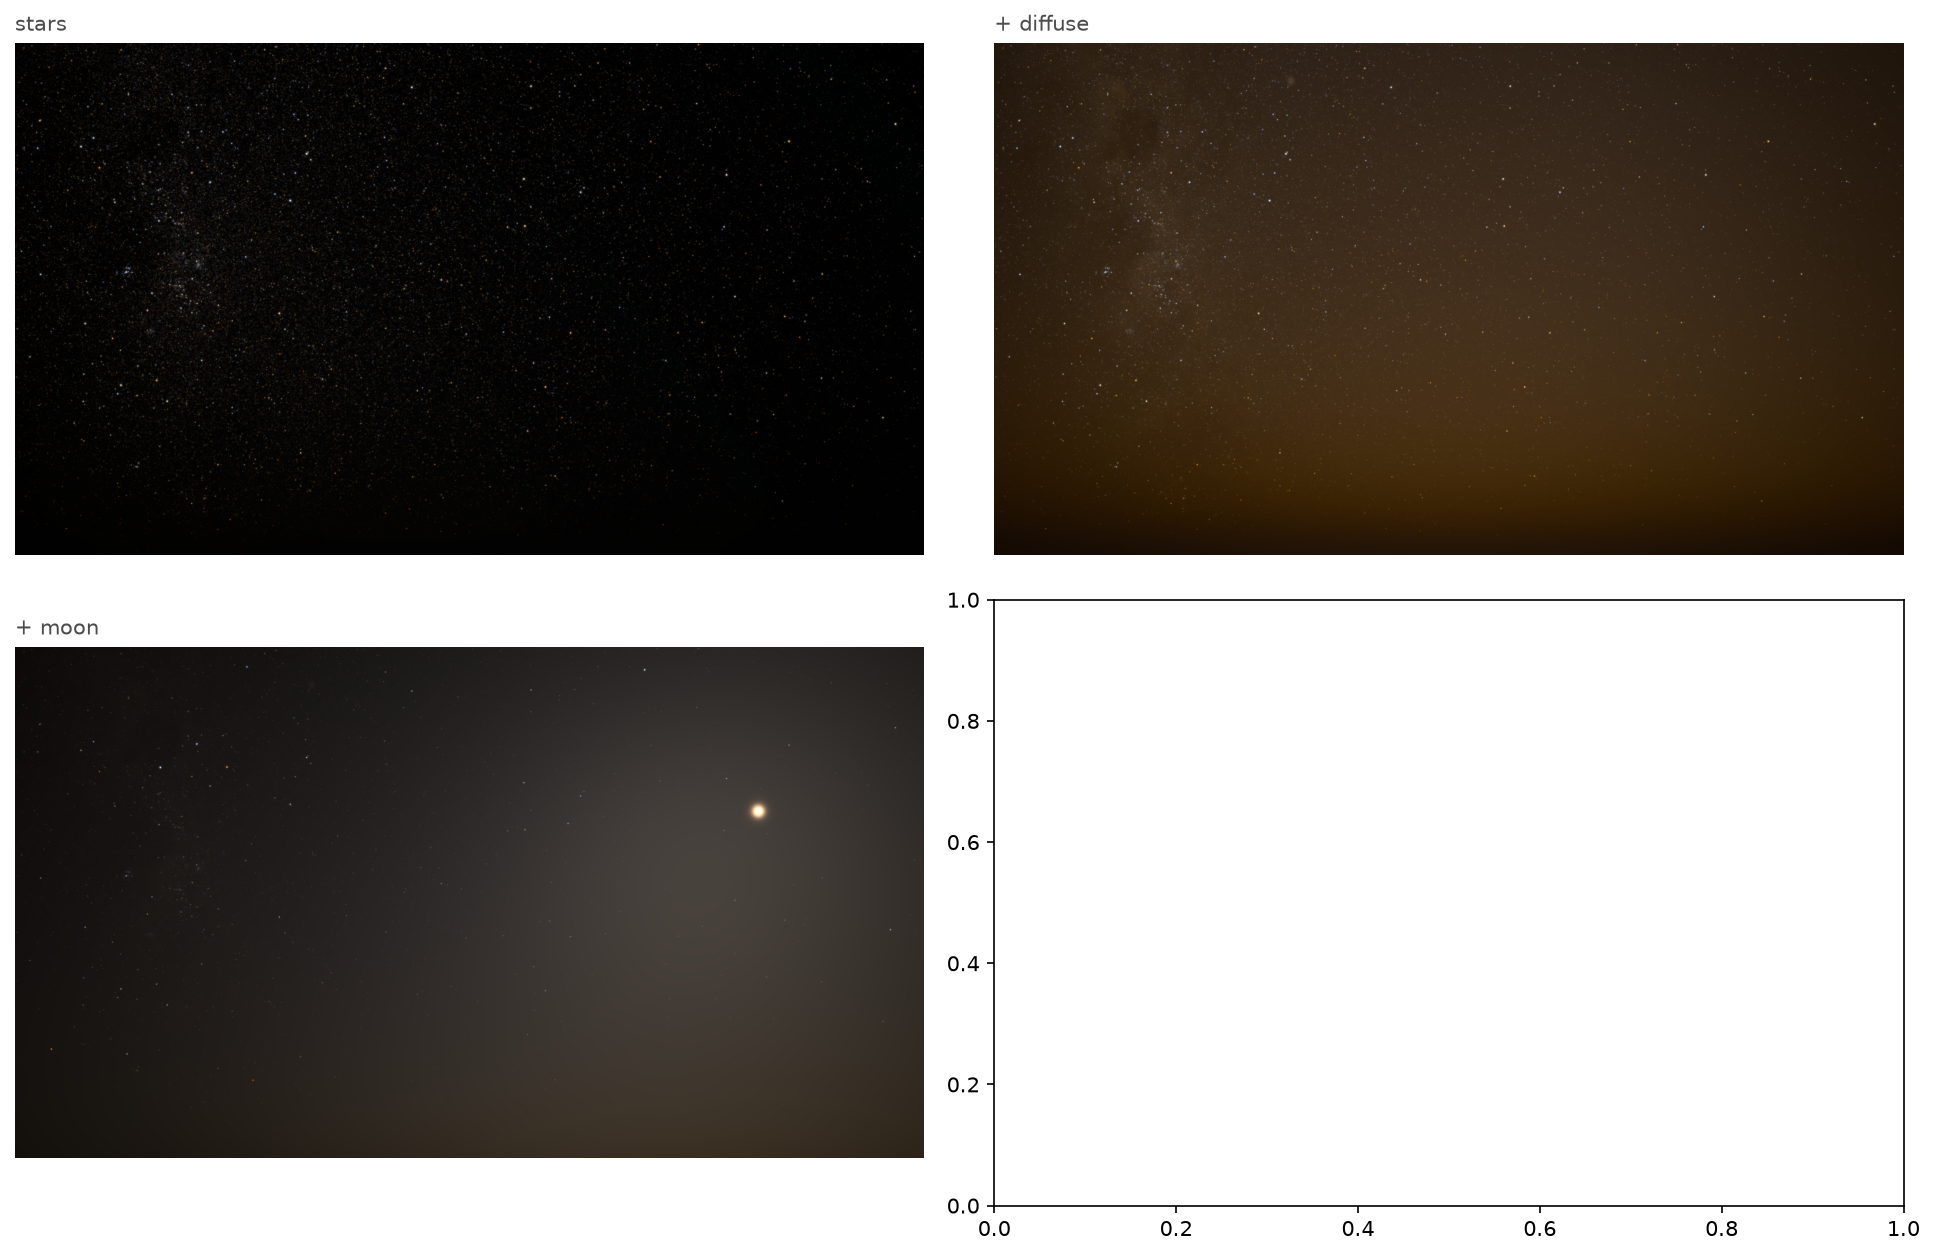

In [14]:
build_up = [
    ("stars", ["stars"]),
    ("+ diffuse", ["stars", "starlight", "zodiacal", "airglow"]),
    ("+ moon", None),
]

frames = {
    label: camera.expose(sky, names) for label, names in build_up
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8.6))
for ax, (label, image) in zip(axes.ravel(), frames.items()):
    if label != "+ moon":
        show(image, curve, label, ax=ax)
    else:
        show(image, moon_curve, label, ax=ax)
    
fig.tight_layout()

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("frames")
output_dir.mkdir(exist_ok=True)

for label, image in frames.items():
    fig, ax = plt.subplots(figsize=(12.8, 7.2), dpi=300)

    if label != "+ moon":
        show(image, curve, label, ax=ax)
    else:
        show(image, moon_curve, label, ax=ax)
    fig.tight_layout()

    # Make the label safe to use as a filename
    filename = label.replace("+ ", "").replace(" ", "_").replace("/", "_")
    fig.savefig(output_dir / f"{filename}.png", dpi=300, bbox_inches="tight")

    plt.close(fig)